# EDA - UHPC Dataset

This notebook performs exploratory data analysis on the Ultra High Performance Concrete (UHPC) dataset, including data cleaning, column selection, and encoding strategy identification.

In [2]:
import pandas as pd
import numpy as np
import re

In [3]:
# Load UHPC dataset with multi-level headers
df = pd.read_csv("UHPC_dataset.csv", encoding="latin-1", header=[0, 2])
print(f"Initial shape: {df.shape}")

Initial shape: (2188, 92)


## 1. Data Loading & Cleaning

In [4]:
all_references = df.iloc[:, -1].replace(r'^\s*$', np.nan, regex=True).ffill()
# Delete mix_id and research paper columns, flatten multi-level index
df_cleaned = df.iloc[1:, 1:-4].reset_index(drop=True)
df_cleaned.columns = df_cleaned.columns.get_level_values(1)

# Assign meaningful column names
column_names = [
    # Binders
    'cement', 'cement_type', 'cement_grade',
    'silica_fume', 'fly_ash', 'fly_ash_type', 'limestone_powder',
    'quartz_powder', 'glass_powder', 'rice_husk_ash', 'metakaolin',
    'ggbfs', 'slag', 'slag_type', 'nano_caco3', 'nano_al2o3',
    'nano_tio2', 'nano_sio2',
    # Fillers & Aggregates
    'filler', 'filler_type', 'sand', 'sand_type', 'sand_max_size',
    # Fibers
    'fiber1_type', 'fiber1_amount', 'fiber1_length', 'fiber1_diameter',
    'fiber1_tensile_strength', 'fiber1_youngs_modulus',
    'fiber2_type', 'fiber2_amount', 'fiber2_length', 'fiber2_diameter',
    'fiber2_tensile_strength', 'fiber2_youngs_modulus',
    # Additives & Mixing
    'water', 'sp_type', 'sp_amount',
    # Curing Conditions
    'curing_method', 'curing_temp', 'curing_humidity', 'curing_pressure',
    # Workability
    'workability_standard', 'slump', 'slump_flow',
    # Compressive Strength (cs)
    'cs_specimen', 'cs_standard', 'cs_1d', 'cs_3d', 'cs_7d',
    'cs_14d', 'cs_21d', 'cs_28d', 'cs_56d', 'cs_90d',
    # Elastic Modulus
    'em_standard', 'elastic_modulus',
    # Tensile Properties
    'tensile_standard', 'split_tensile', 'first_cracking_strength',
    'direct_tensile', 'peak_tensile_strain', 'tensile_elastic_modulus',
    'strain_capacity',
    # Flexural Properties
    'flexural_specimen', 'flexural_standard', 'lop', 'mor',
    'peak_flexural', 'residual_f600', 'residual_f150', 'toughness',
    # Durability & Other
    'durability_standard', 'air_content', 'air_void', 'porosity',
    'water_absorption_standard', 'water_absorption', 'shrinkage_standard',
    'shrinkage_28d', 'shrinkage_56d', 'freeze_thaw_standard',
    'freeze_thaw_cycles', 'rcpt_standard', 'rcpt', 'resistivity_standard',
    'surface_resistivity'
]

df_cleaned.columns = column_names

# Add the last column (index -1) from the original dataframe
df_cleaned['reference'] = all_references.iloc[1:].reset_index(drop=True)
# Update your main df to use this cleaned version
df = df_cleaned
print(f"Cleaned shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")

Cleaned shape: (2187, 88)
Total columns: 88


In [5]:
# Check data types
print("Data types summary:")
print(df.dtypes.value_counts())
print(f"\nMissing values:\n{df.isnull().sum().sum()} total missing values")

Data types summary:
float64    57
str        31
Name: count, dtype: int64

Missing values:
111286 total missing values


## 2. Data Inspection & Filtering

In [6]:
# Remove rows with missing target variable
df = df.dropna(subset=['cs_28d'])
print(f"Rows with 28-day compressive strength data: {len(df)}")

# Define columns to drop (focusing on cs_28d as target)
drop_cols = [
    # Workability measurements
    'workability_standard', 'slump', 'slump_flow',
    # Compressive strength: metadata and other timepoints (keeping only cs_28d)
    'cs_specimen', 'cs_standard', 'cs_1d', 'cs_3d', 'cs_7d',
    'cs_14d', 'cs_21d', 'cs_56d', 'cs_90d',
    # Elastic modulus
    'em_standard', 'elastic_modulus',
    # Tensile properties
    'tensile_standard', 'split_tensile', 'first_cracking_strength',
    'direct_tensile', 'peak_tensile_strain', 'tensile_elastic_modulus',
    'strain_capacity',
    # Flexural properties
    'flexural_specimen', 'flexural_standard', 'lop', 'mor',
    'peak_flexural', 'residual_f600', 'residual_f150', 'toughness',
    # Durability properties
    'durability_standard', 'air_content', 'air_void', 'porosity',
    'water_absorption_standard', 'water_absorption', 'shrinkage_standard',
    'shrinkage_28d', 'shrinkage_56d', 'freeze_thaw_standard',
    'freeze_thaw_cycles', 'rcpt_standard', 'rcpt', 'resistivity_standard',
    'surface_resistivity'
]

# Drop unnecessary columns
df = df.drop(columns=drop_cols)
print(f"Final shape after filtering: {df.shape}")
print(f"Remaining columns: {df.shape[1]}")

Rows with 28-day compressive strength data: 2072
Final shape after filtering: (2072, 44)
Remaining columns: 44


In [7]:
# Data type conversions
# Extract numeric value from curing_pressure using regex (handles cases like "1.2?MPa", "2 MPa")
df['curing_pressure'] = df['curing_pressure'].str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Clean fly_ash_type: extract last character (F or C), strip whitespace, and standardize
df['fly_ash_type'] = df['fly_ash_type'].str.strip().str[-1]  # Get last character (F or C)
df['fly_ash_type'] = df['fly_ash_type'].replace({'F': 'class F', 'C': 'class C'})

# Clean slag_type:
df['slag_type'] = df['slag_type'].str.strip().str.title()

# Clean Filler type
df['filler_type'] = df['filler_type'].str.strip().str.title()

#clean Sand Type
df['sand_type'] = df['sand_type'].str.strip().str.title()

#synergetic fibre
df['fiber2_amount'] = pd.to_numeric(df['fiber2_amount'], errors='coerce')
df['fiber2_length'] = pd.to_numeric(df['fiber2_length'], errors='coerce')


In [8]:
#complicated fiber1_type

def categorize_fiber(val):
    if pd.isna(val):
        return val
    v = val.strip().lower()
    if 'hooked' in v:
        return 'Hooked Steel Fiber'
    elif 'twisted' in v:
        return 'Twisted Steel Fiber'
    elif 'straight' in v or ('steel' in v and 'fiber' in v) or ('steel' in v and 'fibre' in v):
        return 'Straight Steel Fiber'
    elif 'pe' == v or 'polyethylene' in v:
        return 'PE Fiber'
    elif 'pva' in v:
        return 'PVA Fiber'
    elif 'glass' in v:
        return 'Glass Fiber'
    elif 'carbon' in v:
        return 'Carbon Fiber'
    elif 'pp' == v:
        return 'PP Fiber'
    elif 'cellulose' in v:
        return 'Cellulose Fiber'
    elif 'wollastonit' in v:
        return 'Wollastonite Fiber'
    elif 'medium' in v or 'short' in v or 'long' in v:
        return 'Straight Steel Fiber'
    else:
        return val.strip().title()

df['fiber1_type'] = df['fiber1_type'].apply(categorize_fiber)
df['fiber2_type'] = df['fiber2_type'].apply(categorize_fiber)

In [9]:
def categorize_curing(val):
    if pd.isna(val):
        return val
    v = val.strip().lower()
    if 'autoclave' in v:
        return 'Autoclave Curing'
    elif 'steam' in v:
        return 'Steam Curing'
    elif 'hot water' in v or 'warm water' in v or 'warm bath' in v:
        return 'Hot Water Curing'
    elif 'heat' in v or 'hot' in v or 'oven' in v:
        return 'Heat Curing'
    elif 'water' in v or 'moist' in v:
        return 'Water Curing'
    elif 'air' in v:
        return 'Air Curing'
    elif 'standard' in v or 'normal' in v:
        return 'Standard Curing'
    else:
        return val.strip().title()

df['curing_method'] = df['curing_method'].apply(categorize_curing)

df['curing_method'] = df['curing_method'].replace({
    'Curing  At 90 Oc': 'Heat Curing',
    'Stnadrad Curing': 'Standard Curing'
})

### Curing Method Categorization

In [10]:
# Check unique values 

def check_unique(df, col):
    print(f"Unique {col} values:")
    print(list(df[col].unique()))
    print(f"Total unique values: {df[col].nunique()}")
    


check_unique(df, 'cement_type')

Unique cement_type values:
['Type I/II low-alkali portland cement', 'Portland cement ', ' Portland cement', 'High sulfate-resistant cement (Type HS cement)', 'Ordinary Portland cement\r\nASTM C150 type I', 'Portland cement CEM I 52.5 N', ' Portland cement (US) Type I', 'Portland cement CEM I 52.5 R', 'Portland cement type I 52.5 R', 'Type I portland cement', 'CEM I 52.5 PM ES', 'CEMII/A-L42.5R', 'ordinary Portland cement Type I cement', 'portland cement', 'Portland cement Type 1 cement', 'Type III portland cement', 'P.I 42.5 Portland cement', 'ordinary portland cement', 'Portland cement type I 52.5R', 'CEM I-type 42.5 R', 'ordinary Portland cement  42.5 Grade ', 'Type I Portland cement', 'Chinese standard Graded 52.5 P.II type Portland cement', 'Ordinary Portland Cement', 'Portland cement (P.I 42.5) ', 'Type 1 Portland cement', 'CEM II 52.5 R', 'Ordinary Portland\r\nCement (OPC, P.II 52.5)', '52.5 cement', 'Portland cement (CEM 1) with a strength class 52.5 N ', 'Portland cement (CEM 1

### Check Unique Values Helper

### Fiber Type Categorization

In [11]:
import re

cement_regex_map = [
    (r'high.?sulfate|type.?hs',     'HS_cement'),
    (r'type.?iii|type.?3\b',        'OPC_III'),
    (r'white',                       'white_cement'),
    (r'cem.?ii|cem2|cemii',          'CEM_II'),
    (r'blast.?furnace',              'BFS_cement'),
    (r'pozzolan',                    'pozzolan_cement'),
    (r'ggbs',                        'OPC_I_GGBS'),
    (r'53.?grade|grade.?53|\b53\b',  'OPC_53'),
    (r'52[.,]?5',                    'OPC_52.5'),
    (r'42[.,]?5',                    'OPC_42.5'),
]

df['cement_type'] = df['cement_type'].apply(
    lambda val: val if (pd.isna(val) or val in ('unknown_type', 'not_applicable'))
    else next((label for pat, label in cement_regex_map if re.search(pat, str(val).lower())), 'OPC_unknown')
)

print(df['cement_type'].value_counts(dropna=False))




cement_type
OPC_52.5           674
OPC_unknown        605
OPC_42.5           434
HS_cement          158
OPC_53              92
CEM_II              33
OPC_III             32
NaN                 19
white_cement        14
pozzolan_cement      7
OPC_I_GGBS           3
BFS_cement           1
Name: count, dtype: int64


### Cement Type Standardization with Regex

In [12]:
def clean_cement_combined(row):
    ct = str(row['cement_type']).strip() if pd.notna(row['cement_type']) else ''
    cg = str(row['cement_grade']).strip() if pd.notna(row['cement_grade']) else ''

    # special types first — grade doesn't override these
    if ct in ('HS_cement', 'OPC_III', 'CEM_II', 'white_cement',
              'pozzolan_cement', 'OPC_I_GGBS', 'BFS_cement'):
        return ct

    # grade column resolves ambiguous OPC_unknown
    if cg in ('52.5', '52.50'):  return 'OPC_52.5'
    if cg in ('42.5', '42.50'):  return 'OPC_42.5'
    if cg in ('53.0', '53'):     return 'OPC_53'

    # already graded types from cement_type
    if ct == 'OPC_52.5':  return 'OPC_52.5'
    if ct == 'OPC_42.5':  return 'OPC_42.5'
    if ct == 'OPC_53':    return 'OPC_53'

    # ungraded OPC_unknown with no grade info → OPC_I
    if ct == 'OPC_unknown':  return 'OPC_I'

    return 'Unknown'

df['cement_type'] = df.apply(clean_cement_combined, axis=1)
print(df['cement_type'].value_counts(dropna=False))

cement_type
OPC_52.5           698
OPC_I              559
OPC_42.5           456
HS_cement          158
OPC_53              92
CEM_II              33
OPC_III             32
Unknown             19
white_cement        14
pozzolan_cement      7
OPC_I_GGBS           3
BFS_cement           1
Name: count, dtype: int64


### Combined Cement Type & Grade Cleaning

In [13]:
sp_regex_map = [
    (r'vma|viscosity.modif',                                        'VMA'),
    (r'naphthalene|sulfonat',                                       'SNF_SP'),
    (r'acrylic|acrylate|poly.acrylic.ester',                        'Other_Polymer_SP'),
    (r'polycarboxylic\s+ether|polycarboxylic.based|pce|hyperplastic','PCE_HRWRA'),
    (r'polycarboxylate|polycarboxilate|carboxylate.based',          'PCE_SP'),
    (r'hrwra|hrwr|high.range.water|high.performance.water',         'HRWRA'),
]

df['sp_type'] = df['sp_type'].apply(
    lambda val: val if (pd.isna(val) or val in ('unknown_type', 'not_applicable'))
    else next((label for pat, label in sp_regex_map if re.search(pat, val.lower())), 'Unspecified')
)

print(df['sp_type'].value_counts(dropna=False))

sp_type
PCE_SP              1158
PCE_HRWRA            398
Unspecified          218
HRWRA                125
NaN                  120
SNF_SP                26
Other_Polymer_SP      23
VMA                    4
Name: count, dtype: int64


### Superplasticizer Type Standardization

## 3. Feature Encoding Strategy Analysis

In [14]:
# Analyze encoding requirements for each feature
encoding_info = []

for col in df.columns:
    n_unique = df[col].nunique()
    dtype = df[col].dtype

    # Determine encoding strategy based on data type and cardinality
    if pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
        if n_unique == 2:
            encoding = "Binary Encoding"
        elif n_unique <= 10:
            encoding = "One-Hot Encoding"
        else:
            encoding = "Ordinal/Target Encoding"
    elif pd.api.types.is_numeric_dtype(df[col]):
        encoding = "No Encoding"
    else:
        encoding = "Check Manually"

    encoding_info.append([col, dtype, n_unique, encoding])

# Create and display encoding summary
encoding_df = pd.DataFrame(
    encoding_info,
    columns=["Column", "Data Type", "Unique Values", "Type of Encoding"]
)

print(f"Total features to encode: {len(encoding_df)}\n")
display(encoding_df)

# Save encoding report
encoding_df.to_csv("encoding_report.csv", index=False)
print("\n✓ Encoding report saved to 'encoding_report.csv'")

Total features to encode: 44



C:\Users\jasur\AppData\Local\Temp\ipykernel_34948\1108641549.py:9: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


,Column,Data Type,Unique Values,Type of Encoding
0,cement,float64,359,No Encoding
1,cement_type,str,12,Ordinal/Target Encoding
2,cement_grade,float64,3,No Encoding
3,silica_fume,float64,247,No Encoding
4,fly_ash,float64,101,No Encoding
5,fly_ash_type,str,2,Binary Encoding
6,limestone_powder,float64,44,No Encoding
7,quartz_powder,float64,87,No Encoding
8,glass_powder,float64,95,No Encoding
9,rice_husk_ash,float64,19,No Encoding



✓ Encoding report saved to 'encoding_report.csv'


## 4. Data Type Summary

In [15]:
# Check for categorical (object) columns
object_cols = [col for col in df.columns if df[col].dtype == 'object']

print(f"Categorical columns ({len(object_cols)}):\n")
for col in object_cols:
    print(f"{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())
    print()
    
df.to_csv("./Datasets/initial_cleaned.csv")

df.shape

Categorical columns (0):



(2072, 44)

In [16]:
df.describe()

,cement,cement_grade,silica_fume,fly_ash,limestone_powder,quartz_powder,glass_powder,rice_husk_ash,metakaolin,ggbfs,...,fiber2_length,fiber2_diameter,fiber2_tensile_strength,fiber2_youngs_modulus,water,sp_amount,curing_temp,curing_humidity,curing_pressure,cs_28d
count,2072.000000,1274.000000,2072.000000,2072.000000,2072.000000,2072.000000,2072.000000,2072.000000,2072.000000,2072.000000,...,118.000000,118.000000,92.000000,58.000000,2072.000000,2064.000000,1915.000000,838.000000,71.000000,2072.000000
mean,786.164049,48.925432,180.836110,59.545347,13.614966,58.928427,32.377780,2.341776,4.903378,42.046187,...,17.528390,0.124839,2711.413043,111.379310,195.271364,31.865909,56.187833,91.202148,1.839437,150.200085
std,202.424895,4.833798,90.045347,143.872803,62.890751,113.392827,123.678095,22.752543,31.737475,141.964661,...,8.708424,0.106801,625.629497,48.480355,43.374299,17.624763,47.580591,12.183882,0.302125,36.372613
min,170.000000,42.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,400.000000,88.000000,110.000000,2.640000,20.000000,50.000000,1.200000,80.000000
25%,664.000000,42.500000,133.425000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,12.000000,0.030000,2500.000000,88.000000,166.700000,17.470000,20.000000,90.000000,1.850000,124.812500
50%,788.500000,52.500000,197.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.000000,0.160000,3030.000000,88.000000,184.000000,30.000000,23.000000,95.000000,2.000000,145.200000
75%,900.000000,52.500000,230.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,23.750000,0.200000,3030.000000,88.000000,214.400000,44.200000,90.000000,100.000000,2.000000,170.000000
max,1856.700000,53.000000,617.650000,1152.000000,1058.200000,528.000000,1067.000000,481.060000,510.000000,768.000000,...,36.000000,0.500000,4300.000000,250.000000,355.150000,151.700000,210.000000,100.000000,2.000000,298.000000


### Categorical Columns Summary

In [17]:
# Select only float columns
float_cols = df.select_dtypes(include=['float']).columns
df_float = df[float_cols]

cv = (df_float.std() / df_float.mean() * 100).round(1)
summary = pd.DataFrame({
    'mean':   df_float.mean().round(2),
    'median': df_float.median().round(2),
    'std':    df_float.std().round(2),
    'min':    df_float.min().round(2),
    'max':    df_float.max().round(2),
    'cv (%)': cv,
    'skewness': df_float.skew().round(2),
    'outliers': [(df_float[c] > df_float[c].quantile(0.75) + 1.5*df_float[c].std()).sum() 
                for c in df_float.columns] })
print(summary)


                            mean   median     std     min      max  cv (%)  \
cement                    786.16   788.50  202.42  170.00  1856.70    25.7   
cement_grade               48.93    52.50    4.83   42.50    53.00     9.9   
silica_fume               180.84   197.10   90.05    0.00   617.65    49.8   
fly_ash                    59.55     0.00  143.87    0.00  1152.00   241.6   
limestone_powder           13.61     0.00   62.89    0.00  1058.20   461.9   
quartz_powder              58.93     0.00  113.39    0.00   528.00   192.4   
glass_powder               32.38     0.00  123.68    0.00  1067.00   382.0   
rice_husk_ash               2.34     0.00   22.75    0.00   481.06   971.6   
metakaolin                  4.90     0.00   31.74    0.00   510.00   647.3   
ggbfs                      42.05     0.00  141.96    0.00   768.00   337.6   
slag                       17.09     0.00   97.28    0.00  1100.00   569.3   
nano_caco3                  0.54     0.00    4.15    0.00    69.

### Coefficient of Variation Analysis

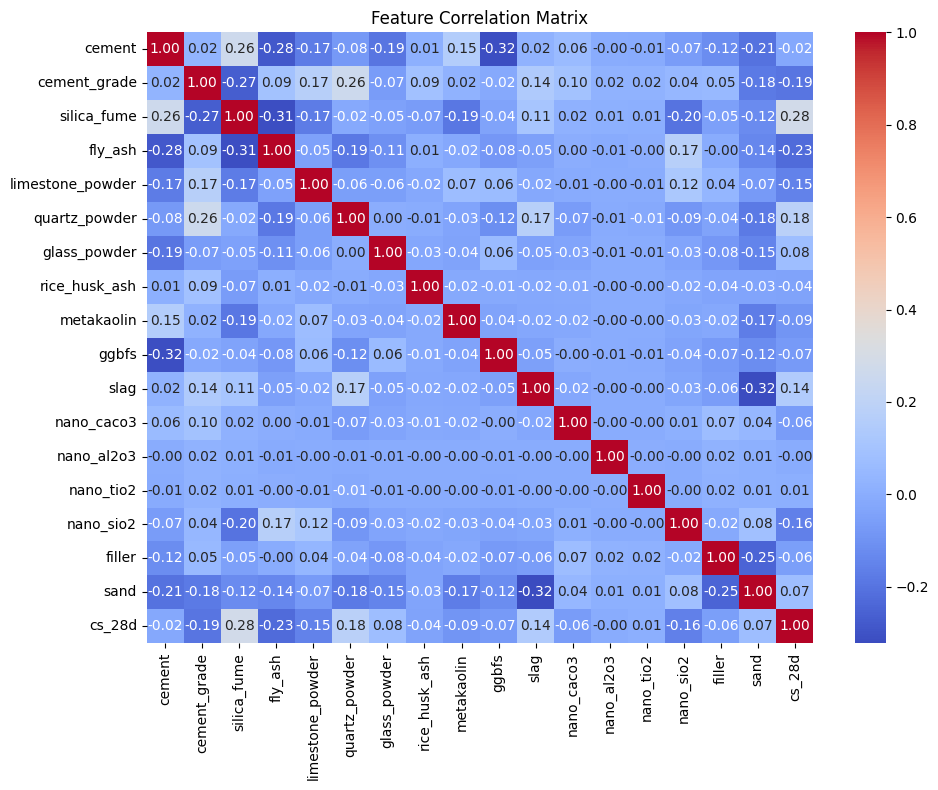

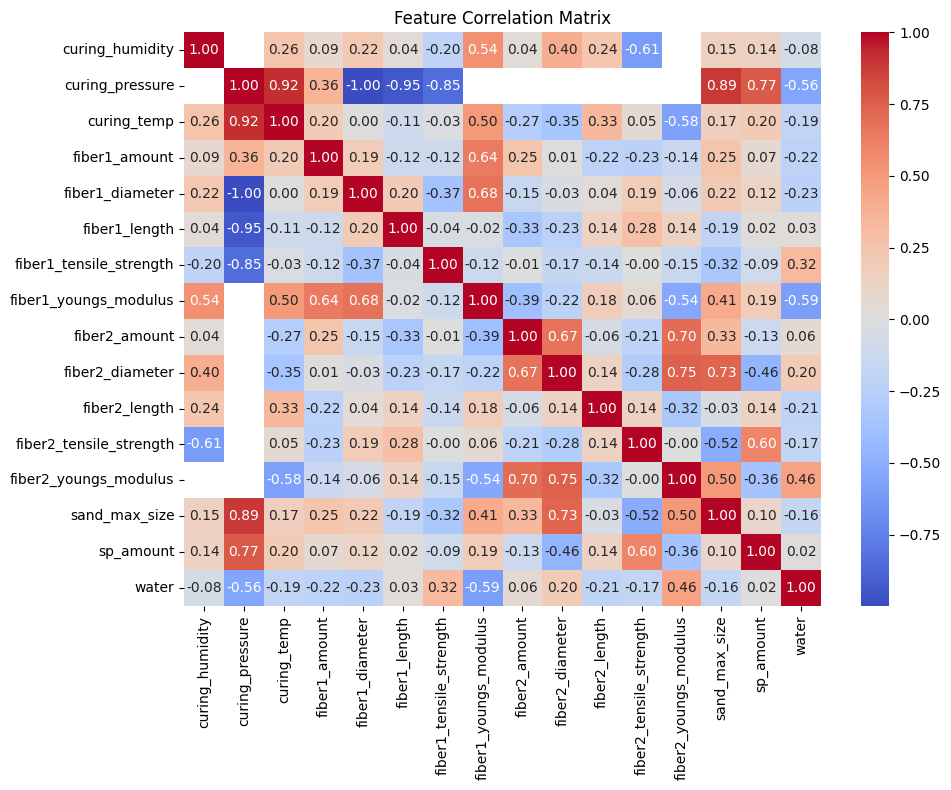

In [18]:
import sys
import os
sys.path.append(os.getcwd())
from utils.plotting import plot_correlation_matrix

# First half of columns + last column
n_cols = len(df_float.columns)
cols_to_select = list(df_float.columns[:n_cols//2]) + [df_float.columns[-1]]
plot_correlation_matrix(df_float[cols_to_select], figsize=(10, 8), cmap="coolwarm", title="Feature Correlation Matrix")

# Remaining columns
rest_cols = df_float.columns.difference(cols_to_select)
plot_correlation_matrix(df_float[rest_cols], figsize=(10, 8), cmap="coolwarm", title="Feature Correlation Matrix")